# Kungnat ca. 1275 Ma paleomagnetic pole

## Geologic Context

- Terrane: Laurentia-Greenland.
- Compiled unit/pole label: Kungnat Ring Dyke.

## Paleomagnetic And Rock Magnetic Data

- B = 4 sites, N = 18 samples; mean direction DEC/INC = 292.0°/-15.4°; K = 455.0.
- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.

## Age Constraints

- Current bracket: nominal age 1275 Ma, lomagage 1273.0 Ma, himagage 1277.0 Ma.
- Compilation method note: 1275.2±1.8 Ma U-Pb baddeleyite from the Ring-Dyke from Larry Heaman and 2 sigma uncertainty date stated in Upton 2013 and referred to in the 2013 paper to be reported in Upton et al., 2003 paper. But there is no description of the sample in the 2003 paper.

## References

- Paleomagnetic source: Piper, J.D.A., Stearn, J.E.F. (1977). Palaeomagnetism of the dyke swarms of the Gardar Igneous Province, South Greenland. Physics Earth Planet. Int., 14, 345-358.
  
- Geochronology / age-constraint note (compilation): 1275.2±1.8 Ma U-Pb and 2 sigma uncertainty date from Upton 2003. Upton, B. (2003). Magmatism of the mid-Proterozoic Gardar Province, South Greenland: Chronology, petrogenesis and geological setting. Lithos, 68(1–2), 43–65. https://doi.org/10.1016/s0024-4937(03)00030-6

- Upton, B. G. J., Macdonald, R., Odling, N., Rämö, O. T., & Bagiński, B. (2013). Kûngnât, revisited. A review of five decades of research into an alkaline complex in South Greenland, with new trace-element and Nd isotopic data. Mineralogical Magazine, 77(4), 523–550. https://doi.org/10.1180/minmag.2013.077.4.11


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the previous Nordic compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed because the underlying directions are not digitized in this repository; the published pole is carried forward into the Nordic compilation format.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'Kungnat Ring Dyke'].iloc[0]

pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': int(float(row['B']))}
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('Kungnat Ring Dyke' + ' pole (Evans et al., 2021 compilation):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  B {pole_mean['n']} sites")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (%REV {row['%REV']})")

Kungnat Ring Dyke pole (Evans et al., 2021 compilation):
  PLAT 3.4  PLON 198.7  A95 3.2  B 4 sites
  mean direction Dec 292.0  Inc -15.4  (%REV 0or100)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
pt.R2_test('Kungnat Ring Dyke', Laurentia_poles)

N = 18 (N < 25; insufficient sample number);
B = 4 (B < 8; insufficient site number);
K = 455 (K ≥ 70; concern about underrepresenting PSV);
A_95 of 3.2 is too small for Deenen criteria of 6.9 for this number of sites


## Euler rotation into the Laurentia reference frame

These rocks belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [4]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 3.4 N / 198.7 E
rotated into the Laurentia frame:        7.4 N / 186.3 E


## Position within the Laurentia apparent polar wander path

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

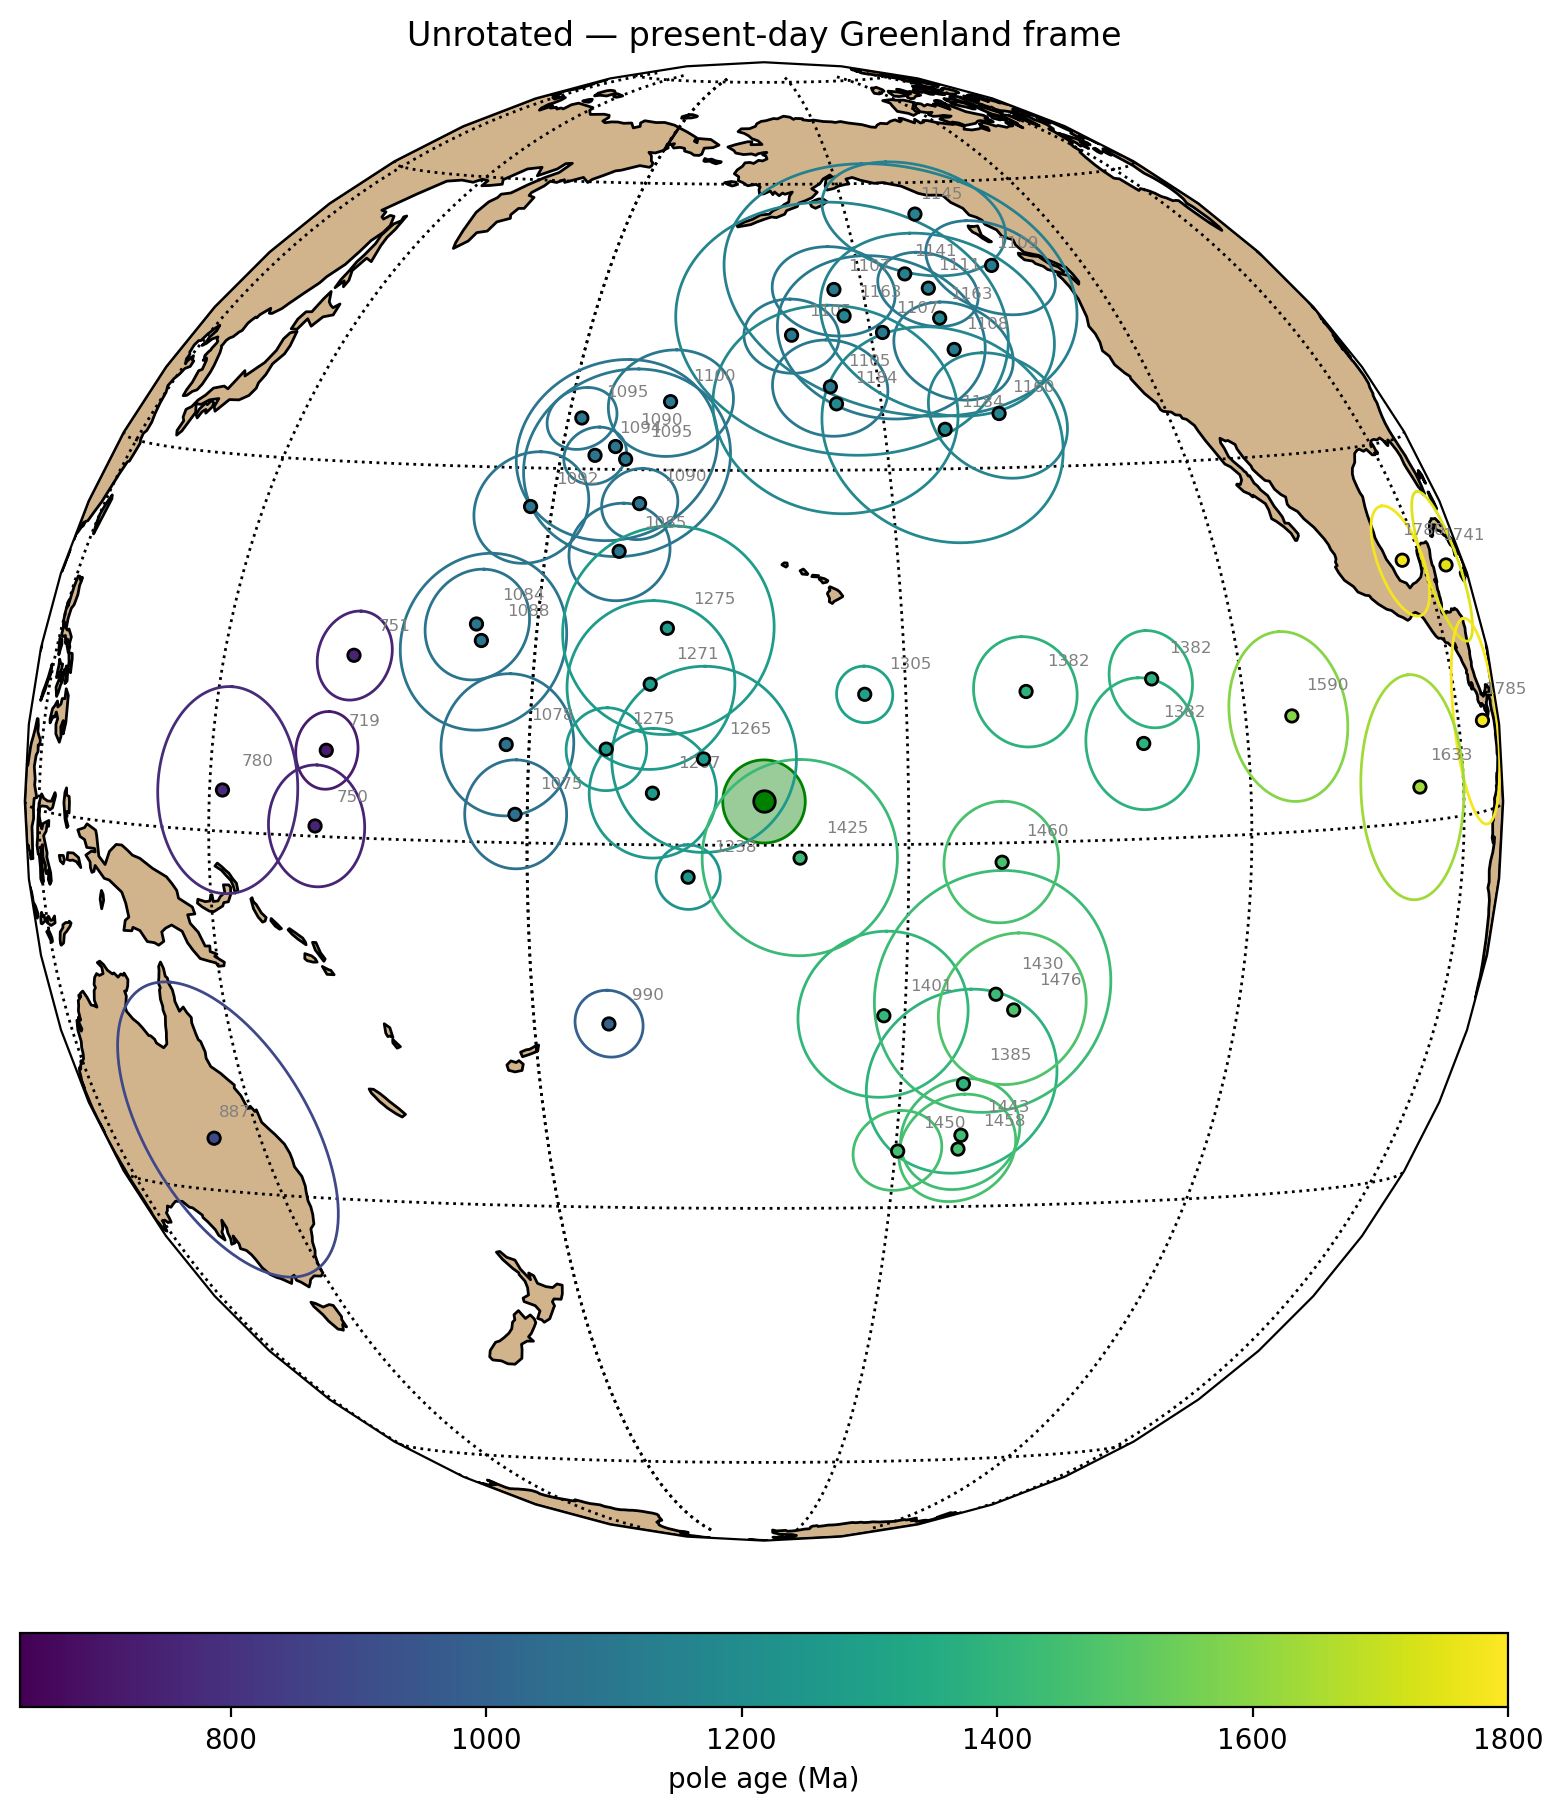

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

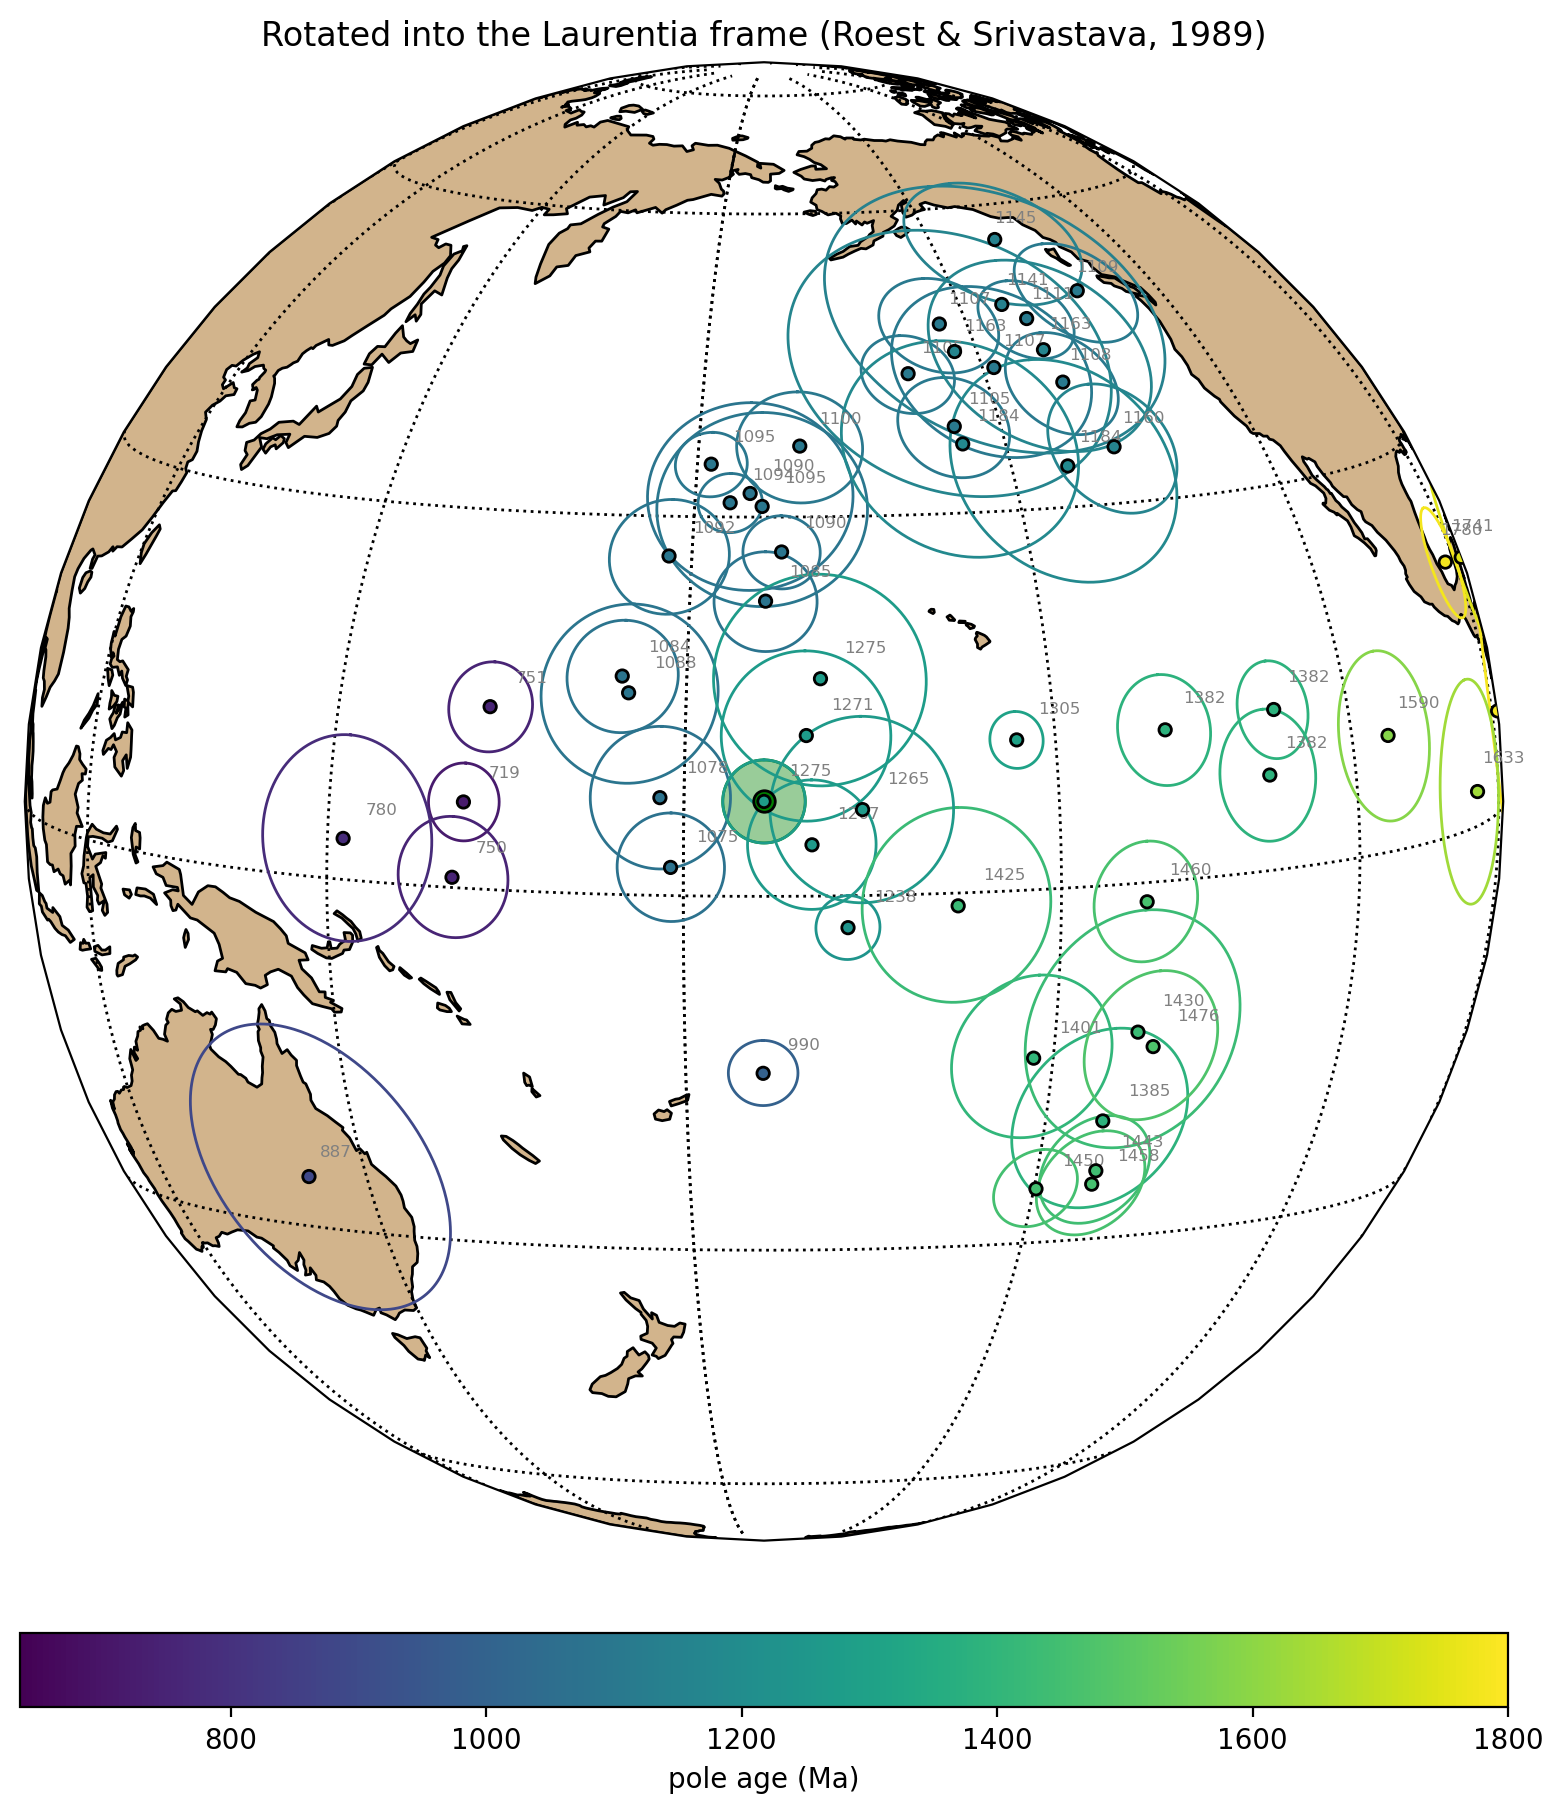

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

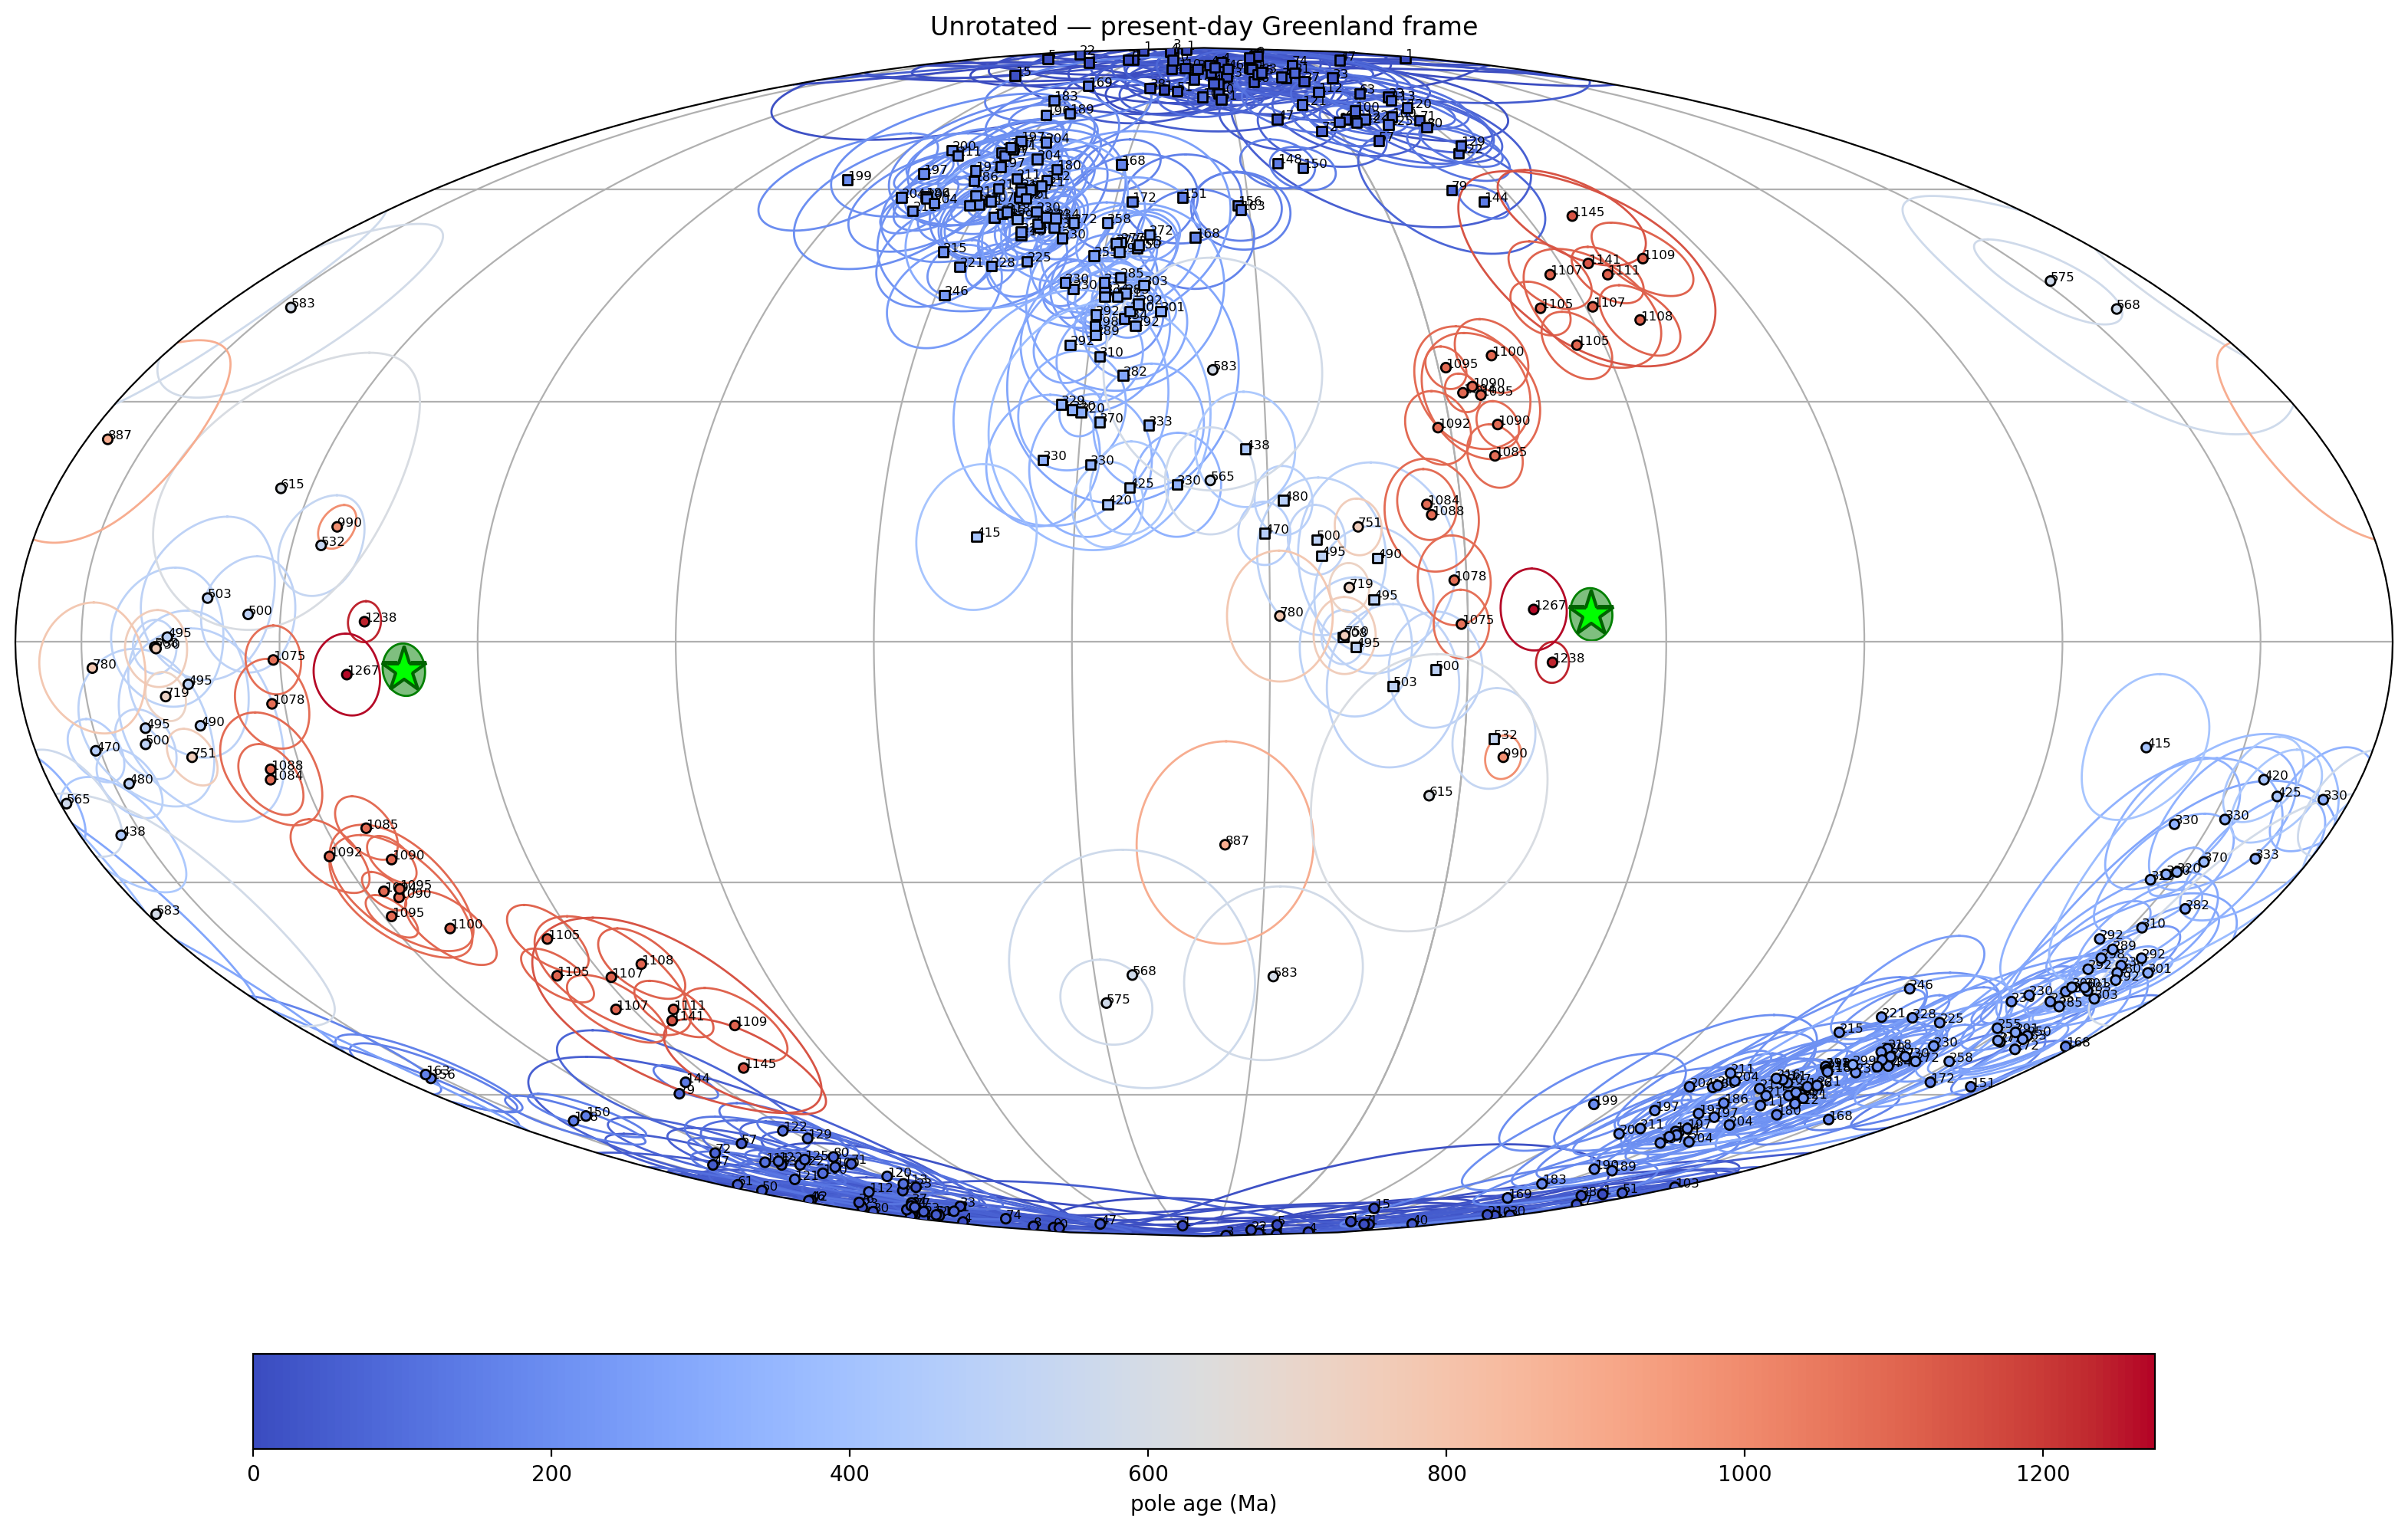

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Kungnat Ring Dyke', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1275, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

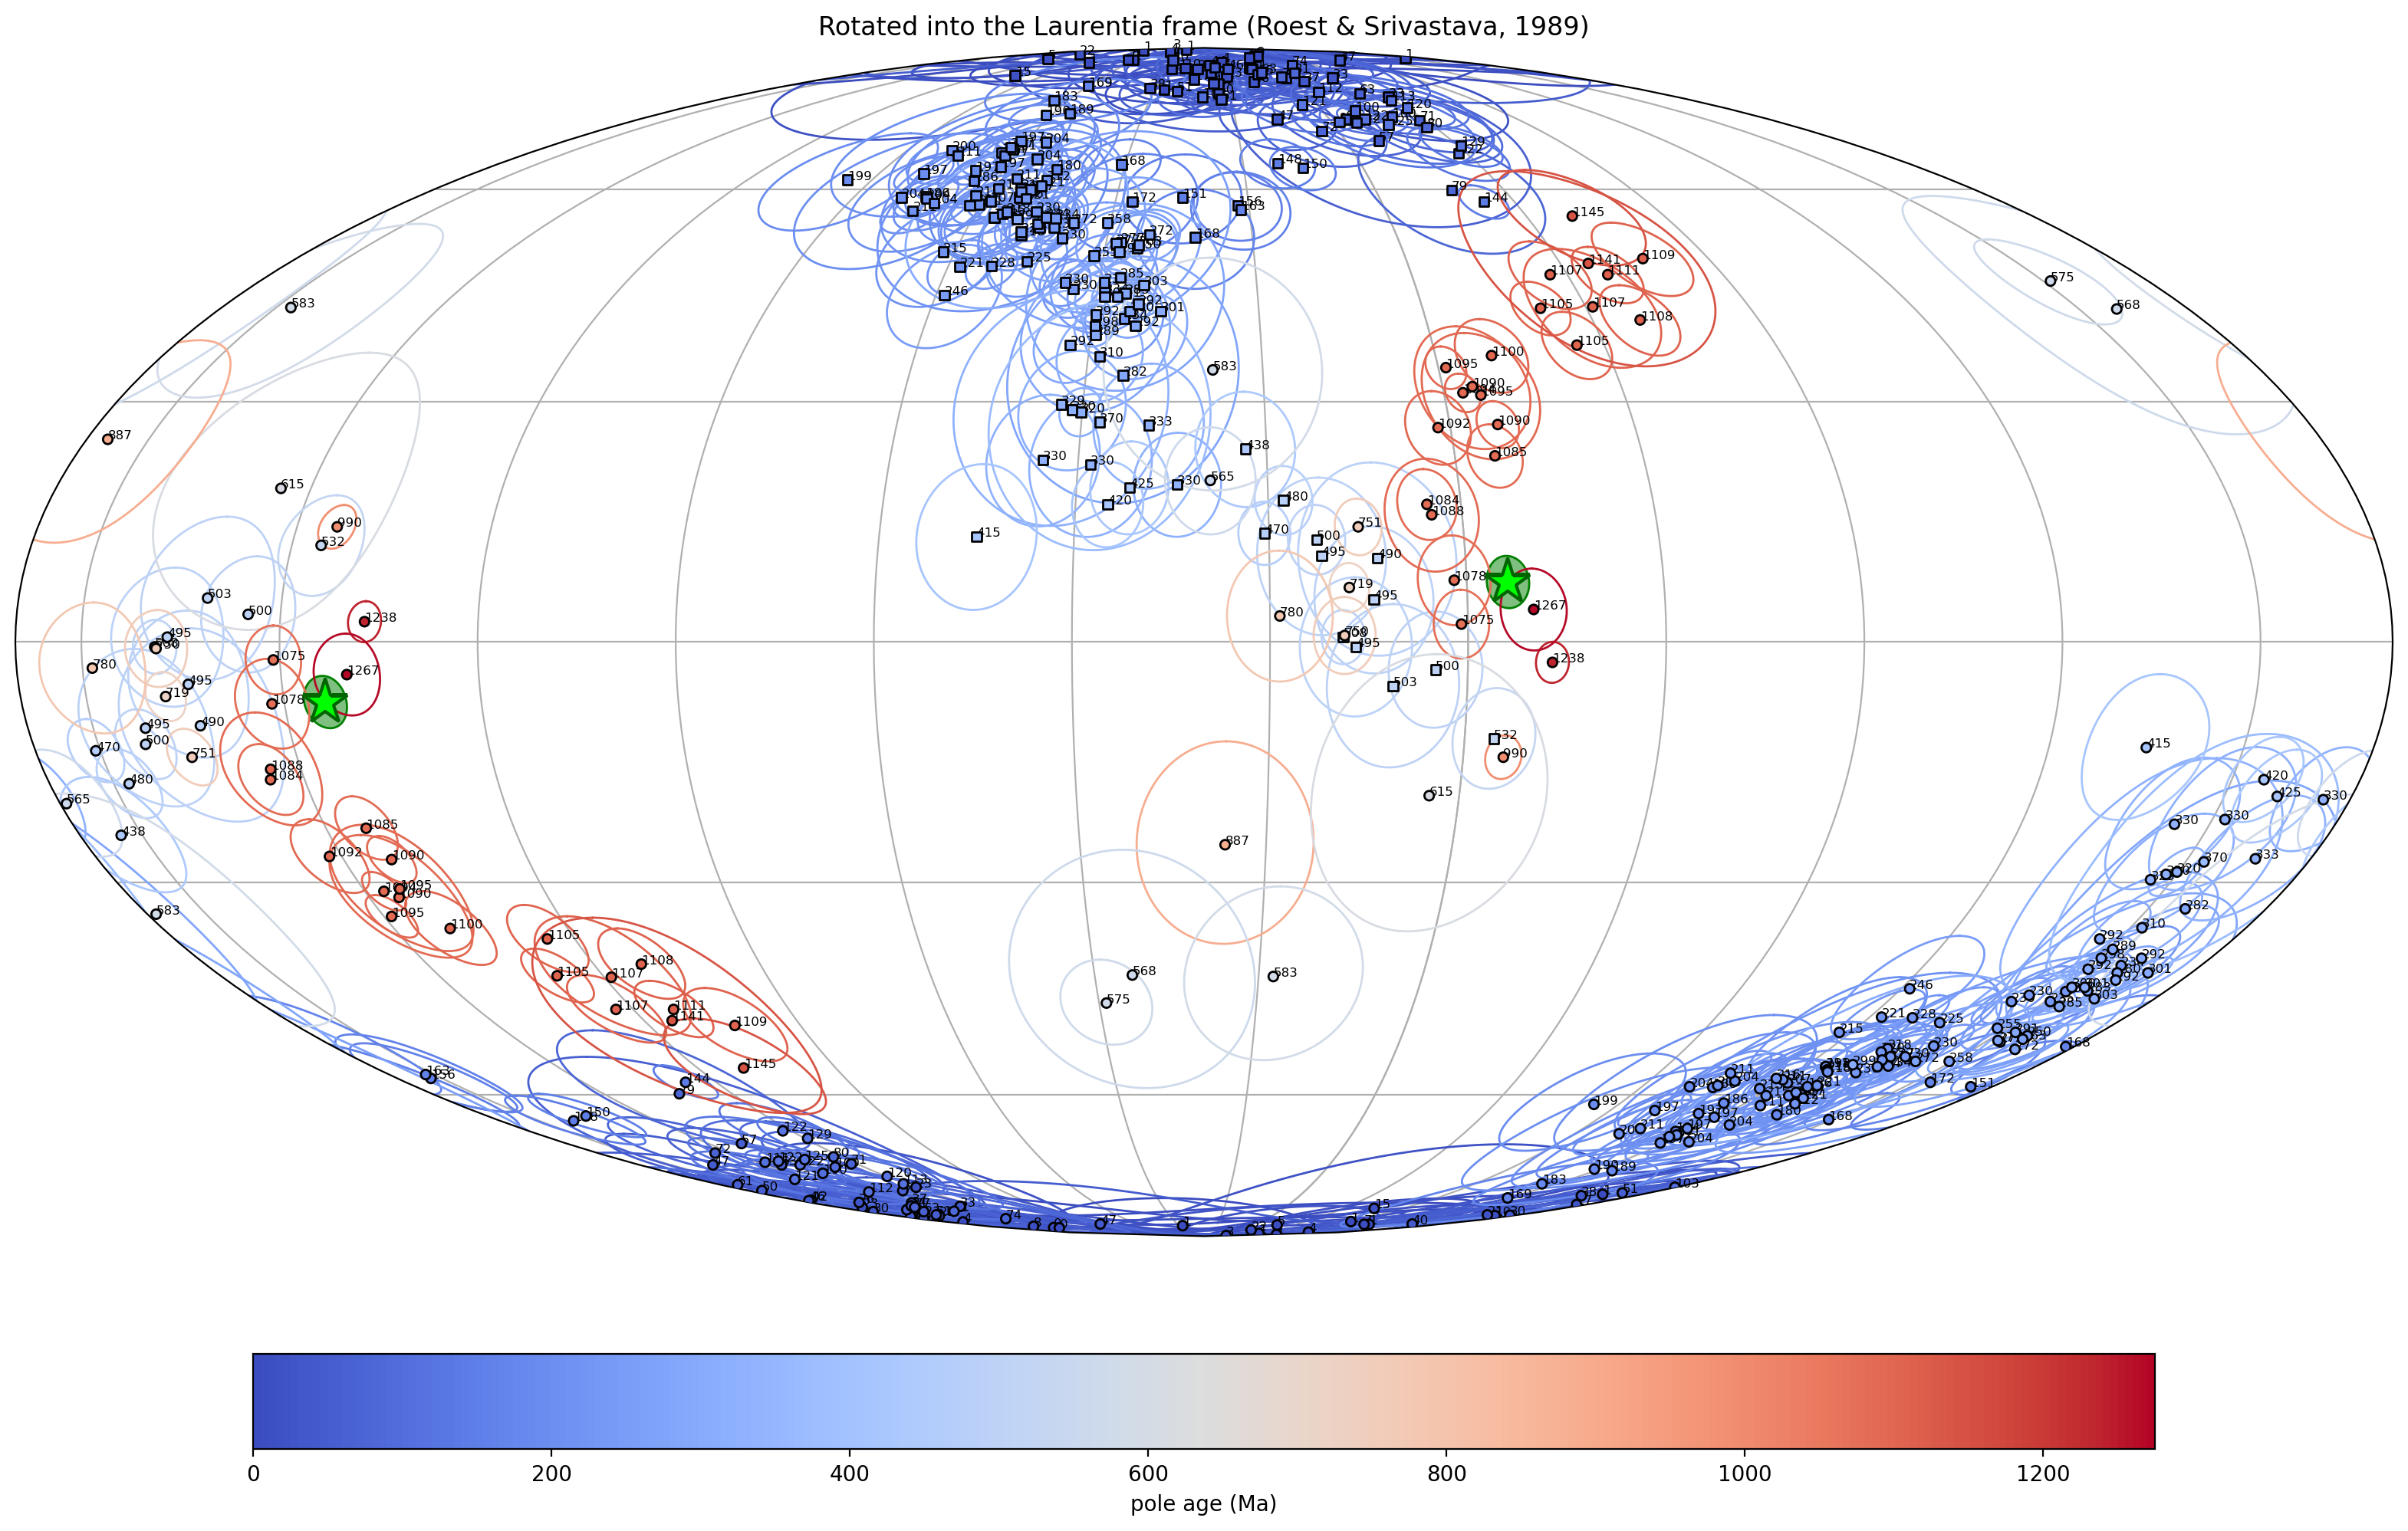

In [8]:
pt.plot_pole_overlap('Kungnat Ring Dyke', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1275, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format. The R-criteria scores, pole position, mean direction, and source-publication metadata are carried from the Evans et al. (2021) compilation; the nominal age, age bounds (lomagage/himagage), and the compilation method note are taken from the age-constraint section of the first markdown cell. The pole is exported in its unrotated, present-day Greenland coordinates; the rotation into the Laurentia frame is applied above only for the APWP comparison.

In [9]:
# R-criteria from the source compilation (R1 age = 1 for this dated pole;
# the Evans '4' field-test column is 0 here, so R4 contributes 0)
R2, R3, R5, R6, R7 = (int(float(row[k])) for k in ['2', '3', '5', '6', '7'])
R4 = '' if float(row['4']) == 0 else 'c'

# published grand mean / compilation pole (no per-site directions digitized here):
# represent it with a single placeholder "sites" row carrying the count and tilt
sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                       'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Kungnat Ring Dyke',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='Characteristic remanent magnetization; Kungnat ring dyke mean (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=R2, R3=R3, R4=R4, R5=R5, R6=R6, R7=R7, Grade=row['Grade'],
    nominal_age=1275, lomagage=1273, himagage=1277,
    REF_method='1275.2 +/- 1.8 Ma U-Pb date (2 sigma) from Upton (2003).',
    POLE_AUTHORS=row['POLE AUTHORS'],
    YEAR=int(float(row['YEAR'])),
    JOURNAL=row['JOURNAL'],
    VOLUME=str(row['VOLUME']),
    VPAGES=str(row['VPAGES']),
    TITLE=row['TITLE'],
    COMMENT='Pole taken from the Evans et al. (2021) Laurentia compilation (Piper & Stearn, 1977); no site-level directions yet compiled.'
)
pt.save_nordic_summary(summary, '1275_Kungnat')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Kungnat Ring Dyke,,Characteristic remanent magnetization; Kungnat...,,0,61.2,311.7,4,18,...,1277,1275.2 +/- 1.8 Ma U-Pb date (2 sigma) from Upt...,Kungnat Ring Dyke,"Piper, J.D.A., Stearn, J.E.F.",1977,Physics Earth Planet. Int.,14,345-358,Palaeomagnetism of the dyke swarms of the Gard...,Pole taken from the Evans et al. (2021) Lauren...
